In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pathlib
import sys
import pandas as pd

In [2]:
exp_utils_path = pathlib.Path("../../../../exp_utils")
sys.path.insert(0, str(exp_utils_path.resolve()))

# Criando o cubo

In [3]:
from explorationUtils import ExplorationCube

As dimensões da área teste 1 são: (126, 251, 32)

In [4]:
top_left_point = (0, 0)
bottom_right_point = (125, 250)
depth = 32
cube = ExplorationCube(top_left_point, bottom_right_point, depth)

# Posição dos poços

In [5]:
wells_coords = [(34, 97), (98, 46), (55, 30), (101, 132), (33, 184)]

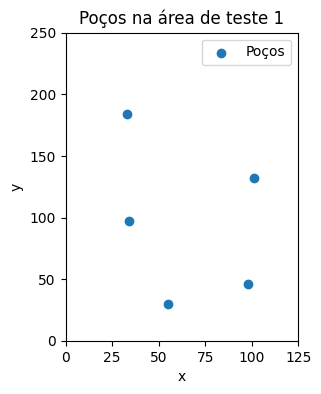

In [6]:
plt.figure(figsize=(3, 4))
x = [coords[0] for coords in wells_coords]
y = [coords[1] for coords in wells_coords]
plt.scatter(x, y, label="Poços")
plt.title("Poços na área de teste 1")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(0, 250)
plt.xlim(0, 125)
plt.legend()
plt.show()

Entretanto, o poço mais ao topo da esquerda será escolhido como um poço de teste. Dessa forma, ele não deve fazer parte dos cálculos a seguir.

In [7]:
wells_coords = wells_coords[:-1]
wells_coords

[(34, 97), (98, 46), (55, 30), (101, 132)]

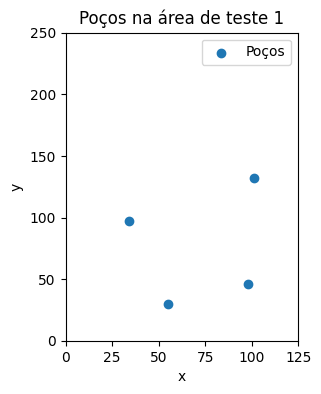

In [8]:
plt.figure(figsize=(3, 4))
x = [coords[0] for coords in wells_coords]
y = [coords[1] for coords in wells_coords]
plt.scatter(x, y, label="Poços")
plt.title("Poços na área de teste 1")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(0, 250)
plt.xlim(0, 125)
plt.legend()
plt.show()

In [9]:
for well_coord in wells_coords:
    cube.add_well_at(well_coord[0], well_coord[1])

# Número máximo de pontos a serem preditos

In [10]:
cube.max_predictable_points_possible()

1011904

# Número de iterações para completar esse cubo

In [11]:
max_it = cube.its_to_predict_complete()
print(max_it)

118


# Pontos preditos por iteração e o acumulado

In [12]:
num_predicted = list()
for i in range(1, max_it):
    num_predicted.append(cube.num_predicted_at_it(i))

In [13]:
num_pred_diff = list()
num_pred_diff.append(num_predicted[0])
for i in range(1, len(num_predicted)):
    num_pred_diff.append(num_predicted[i] - num_predicted[i-1])

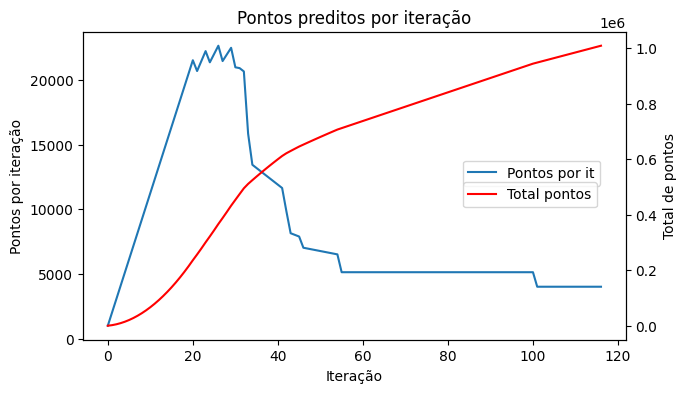

In [14]:
legend_x_pctg = 0.7
plt.figure(figsize=(7, 4))
plt.plot(range(len(num_pred_diff)),num_pred_diff, label="Pontos por it")
plt.ylabel('Pontos por iteração')
plt.xlabel('Iteração')
plt.legend(loc=(legend_x_pctg, 0.5))

axes2 = plt.twinx()
plt.ylabel("Num pontos")
plt.plot(num_predicted, color="red", label="Total pontos")
axes2.set_ylabel('Total de pontos')

plt.title("Pontos preditos por iteração")
plt.legend(loc=(legend_x_pctg, 0.43))